# Evaluation

This notebook loads a trained neural network surrogate and compares predicted aerodynamic polars against available original XFOIL data.

**Inputs:** NACA 4-digit code, Reynolds number, Mach number.

**AoA sweep:** -5° to +15° (step 0.5°).

**Outputs:** For each case, the notebook saves three PNG plots in:
`C:\Users\matte\PyCharmMiscProject\aero-surrogate\reports\evaluation_plots`

- $C_L$ vs $\alpha$
- $C_D$ vs $\alpha$
- $C_L$ vs $C_D$


In [19]:
# ============================================================
# 0) Imports and paths
# ============================================================
import os
import re
import sys
import glob
import math
from pathlib import Path
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# Project root (assumes notebook is in /notebooks)
ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data" / "processed"
TRAINED_DIR = DATA_DIR / "trained_models"
TRAIN_NPZ = DATA_DIR / "data_for_training.npz"
MODEL_INFO_NPY = DATA_DIR / "model_info.npy"
TRAIN_ROWS_CSV = DATA_DIR / "xfoil_dataset_rows.csv"
ORIGINAL_POLARS_DIR = DATA_DIR / "original_polars"

# Output directory requested by the user
OUT_DIR = Path(r"C:\Users\matte\PyCharmMiscProject\aero-surrogate\reports\evaluation_plots")

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("TRAINED_DIR:", TRAINED_DIR)
print("TRAIN_ROWS_CSV exists:", TRAIN_ROWS_CSV.exists())
print("ORIGINAL_POLARS_DIR exists:", ORIGINAL_POLARS_DIR.exists())
print("OUT_DIR:", OUT_DIR)

ROOT: C:\Users\matte\PyCharmMiscProject\aero-surrogate
DATA_DIR: C:\Users\matte\PyCharmMiscProject\aero-surrogate\data\processed
TRAINED_DIR: C:\Users\matte\PyCharmMiscProject\aero-surrogate\data\processed\trained_models
TRAIN_ROWS_CSV exists: True
ORIGINAL_POLARS_DIR exists: True
OUT_DIR: C:\Users\matte\PyCharmMiscProject\aero-surrogate\reports\evaluation_plots


In [20]:
# ============================================================
# 1) Generic model + helpers
# ============================================================
class GenericModel(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_layers: List[int],
                 activation: str = "relu", dropout: float = 0.0):
        super().__init__()

        act_map = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}
        if activation.lower() not in act_map:
            raise ValueError(f"Unsupported activation: {activation}. Supported: {list(act_map.keys())}")
        act = act_map[activation.lower()]

        layers: List[nn.Module] = []
        in_dim = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(in_dim, h))
            layers.append(act())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(float(dropout)))
            in_dim = h

        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def parse_naca_code(naca_str: str) -> int:
    s = naca_str.strip().lower()
    s = s.replace("naca", "")
    s = re.sub(r"[^0-9]", "", s)
    if len(s) == 0:
        raise ValueError("NACA code empty.")
    if len(s) > 4:
        s = s[-4:]
    return int(s)


def naca_str_4(naca_int: int) -> str:
    return f"{naca_int:04d}"


def list_trained_models(trained_dir: Path) -> Dict[str, Dict[str, Path]]:
    out: Dict[str, Dict[str, Path]] = {}
    if not trained_dir.exists():
        return out

    for p in trained_dir.glob("*.pth"):
        name = p.stem  # e.g. 'medium_best' or 'medium_weights'
        if name.endswith("_best"):
            base = name[:-5]
            out.setdefault(base, {})["best"] = p
        elif name.endswith("_weights"):
            base = name[:-8]
            out.setdefault(base, {})["weights"] = p
        else:
            out.setdefault(name, {})["file"] = p
    return out


def load_normalization(npz_path: Path):
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing normalization file: {npz_path}")

    data = np.load(npz_path)
    X_mean = torch.tensor(data["X_mean"], dtype=torch.float32)
    X_std  = torch.tensor(data["X_std"], dtype=torch.float32)
    Y_mean = torch.tensor(data["Y_mean"], dtype=torch.float32)
    Y_std  = torch.tensor(data["Y_std"], dtype=torch.float32)

    # Avoid division by zero
    X_std = torch.where(X_std == 0, torch.ones_like(X_std), X_std)
    Y_std = torch.where(Y_std == 0, torch.ones_like(Y_std), Y_std)

    return X_mean, X_std, Y_mean, Y_std


def load_model_info(model_info_path: Path) -> Dict:
    if not model_info_path.exists():
        raise FileNotFoundError(f"Missing model_info.npy: {model_info_path}")
    return np.load(model_info_path, allow_pickle=True).item()


def build_model(model_name: str, model_info: Dict) -> GenericModel:
    if model_name not in model_info:
        raise ValueError(f"Unknown model '{model_name}'. Available: {list(model_info.keys())}")
    cfg = model_info[model_name]
    return GenericModel(
        input_dim=int(cfg["input_dim"]),
        output_dim=int(cfg["output_dim"]),
        hidden_layers=list(cfg["layers"]),
        activation=str(cfg["activation"]),
        dropout=float(cfg["dropout"]),
    )


def load_weights(model: nn.Module, weights_path: Path) -> None:
    if not weights_path.exists():
        raise FileNotFoundError(f"Missing weights: {weights_path}")
    state = torch.load(weights_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()


def clear_output_dir(out_dir: Path) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    removed = 0
    for p in out_dir.glob("*.png"):
        try:
            p.unlink()
            removed += 1
        except Exception as e:
            print(f"[WARN] Could not delete {p}: {e}")
    print(f"Cleared {removed} PNG(s) in {out_dir}")

In [21]:
# ============================================================
# 2) Original data access (known vs unknown)
# ============================================================
def load_training_rows(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"Training/original rows CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)
    for c in ["naca", "Re", "Mach", "alpha_deg", "CL", "CD"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["naca", "Re", "Mach", "alpha_deg", "CL", "CD"])
    return df


def available_known_sets(df_rows: pd.DataFrame):
    naca_list = sorted(df_rows["naca"].astype(int).unique().tolist())
    re_list = sorted(df_rows["Re"].unique().tolist())
    mach_list = sorted(df_rows["Mach"].unique().tolist())
    return naca_list, re_list, mach_list


def subset_original_known(df_rows: pd.DataFrame, naca: int, Re: float, Mach: float) -> Tuple[pd.DataFrame, Dict]:
    dfn = df_rows[df_rows["naca"].astype(int) == int(naca)].copy()
    if len(dfn) == 0:
        return pd.DataFrame(), {"naca_found": False}

    re_vals = np.array(sorted(dfn["Re"].unique()))
    m_vals  = np.array(sorted(dfn["Mach"].unique()))

    Re_sel = float(re_vals[np.argmin(np.abs(re_vals - Re))])
    Mach_sel = float(m_vals[np.argmin(np.abs(m_vals - Mach))])

    dfs = dfn[(dfn["Re"] == Re_sel) & (dfn["Mach"] == Mach_sel)].sort_values("alpha_deg").copy()
    meta = {
        "naca_found": True,
        "Re_selected": Re_sel,
        "Mach_selected": Mach_sel,
        "Re_exact": bool(np.isclose(Re_sel, Re)),
        "Mach_exact": bool(np.isclose(Mach_sel, Mach)),
    }
    return dfs, meta


_UNKNOWN_RE = re.compile(r"^(naca\d{4})_Re([0-9.]+e[+-]\d+)_M([0-9.]+)\.csv$", re.IGNORECASE)

def index_unknown_originals(folder: Path) -> pd.DataFrame:
    rows = []
    if not folder.exists():
        return pd.DataFrame(columns=["naca_str","naca_int","Re","Mach","path"])

    for p in folder.glob("*.csv"):
        m = _UNKNOWN_RE.match(p.name)
        if not m:
            continue
        naca_s = m.group(1).lower()
        naca_i = int(naca_s.replace("naca", ""))
        Re = float(m.group(2))
        Mach = float(m.group(3))
        rows.append({"naca_str": naca_s, "naca_int": naca_i, "Re": Re, "Mach": Mach, "path": p})

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    return df.sort_values(["naca_int","Re","Mach"]).reset_index(drop=True)


def subset_original_unknown(df_index: pd.DataFrame, naca: int, Re: float, Mach: float) -> Tuple[pd.DataFrame, Dict]:
    dfn = df_index[df_index["naca_int"] == int(naca)].copy()
    if len(dfn) == 0:
        return pd.DataFrame(), {"naca_found": False}

    re_log = np.log10(dfn["Re"].values)
    m_val  = dfn["Mach"].values

    target = np.array([np.log10(Re), Mach])
    X = np.column_stack([re_log, m_val])

    dist = np.linalg.norm(X - target[None, :], axis=1)
    k = int(np.argmin(dist))
    row = dfn.iloc[k]

    df = pd.read_csv(row["path"])
    cols = {c.lower(): c for c in df.columns}
    alpha_col = cols.get("alpha") or cols.get("alpha_deg") or cols.get("a") or df.columns[0]
    cl_col = cols.get("cl") or df.columns[1]
    cd_col = cols.get("cd") or df.columns[2]

    df_out = pd.DataFrame({
        "alpha_deg": pd.to_numeric(df[alpha_col], errors="coerce"),
        "CL": pd.to_numeric(df[cl_col], errors="coerce"),
        "CD": pd.to_numeric(df[cd_col], errors="coerce"),
    }).dropna().sort_values("alpha_deg")

    meta = {
        "naca_found": True,
        "Re_selected": float(row["Re"]),
        "Mach_selected": float(row["Mach"]),
        "file": str(row["path"]),
        "Re_exact": bool(np.isclose(float(row["Re"]), Re)),
        "Mach_exact": bool(np.isclose(float(row["Mach"]), Mach)),
    }
    return df_out, meta

In [22]:
# ============================================================
# 3) Prediction + plotting
# ============================================================
def predict_polar(
    model: nn.Module,
    naca: int,
    Re: float,
    Mach: float,
    alphas: np.ndarray,
    X_mean: torch.Tensor,
    X_std: torch.Tensor,
    Y_mean: torch.Tensor,
    Y_std: torch.Tensor,
    device: str = "cpu",
) -> pd.DataFrame:
    X = np.column_stack([
        np.full_like(alphas, float(naca), dtype=float),
        np.full_like(alphas, float(Re), dtype=float),
        np.full_like(alphas, float(Mach), dtype=float),
        alphas.astype(float),
    ]).astype(np.float32)

    Xt = torch.tensor(X, dtype=torch.float32, device=device)
    Xt_norm = (Xt - X_mean.to(device)) / X_std.to(device)

    with torch.no_grad():
        Yt_norm = model(Xt_norm)
    Yt = Yt_norm * Y_std.to(device) + Y_mean.to(device)
    Y = Yt.cpu().numpy()

    return pd.DataFrame({"alpha_deg": alphas, "CL": Y[:, 0], "CD": Y[:, 1]})


def save_plot_cl_alpha(pred: pd.DataFrame, orig: Optional[pd.DataFrame], title: str, out_path: Path) -> None:
    plt.figure()
    plt.plot(pred["alpha_deg"], pred["CL"], label="NN")
    if orig is not None and len(orig) > 0:
        plt.plot(orig["alpha_deg"], orig["CL"], label="Original")
    plt.xlabel("alpha [deg]")
    plt.ylabel("CL [-]")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()


def save_plot_cd_alpha(pred: pd.DataFrame, orig: Optional[pd.DataFrame], title: str, out_path: Path) -> None:
    plt.figure()
    plt.plot(pred["alpha_deg"], pred["CD"], label="NN")
    if orig is not None and len(orig) > 0:
        plt.plot(orig["alpha_deg"], orig["CD"], label="Original")
    plt.xlabel("alpha [deg]")
    plt.ylabel("CD [-]")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()


def save_plot_cl_cd(pred: pd.DataFrame, orig: Optional[pd.DataFrame], title: str, out_path: Path) -> None:
    plt.figure()
    plt.plot(pred["CD"], pred["CL"], label="NN")
    if orig is not None and len(orig) > 0:
        plt.plot(orig["CD"], orig["CL"], label="Original")
    plt.xlabel("CD [-]")
    plt.ylabel("CL [-]")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()


AVAILABLE MODELS (trained weights found):
  - deep      : best, weights
  - dropout   : best, weights
  - medium    : best, weights
  - small     : best, weights

KNOWN NACA profiles (from xfoil_dataset_rows.csv): 158
  Examples: naca0006, naca0009, naca0012, naca0015, naca0018, naca0021, naca0206, naca0209, naca0212, naca0215, naca0218, naca0221, naca0306, naca0309, naca0312, naca0315, naca0318, naca0321, naca0406, naca0409 ...
  Re range:   1e+06 .. 6.4e+07
  Mach range: 0.100 .. 0.850

UNKNOWN original polars available (from data/processed/original_polars): 86 files
  NACA options: naca0006, naca0008, naca0010, naca0012, naca0015, naca0018, naca0020
  Re range:   5e+04 .. 5e+06
  Mach range: 0.200 .. 0.800

AoA sweep is fixed to: -5 to 15 deg, step 0.5 deg

Cleared 9 PNG(s) in C:\Users\matte\PyCharmMiscProject\aero-surrogate\reports\evaluation_plots
[INFO] Requested (Re, Mach) not exactly available in unknown originals.
       Using nearest file: C:\Users\matte\PyCharmMiscProject\a

,alpha_deg,CL,CD
0,-5.0,-0.481137,0.000817
1,-4.5,-0.426837,0.001242
2,-4.0,-0.372486,0.001666
3,-3.5,-0.317895,0.002088
4,-3.0,-0.263304,0.002509


,alpha_deg,CL,CD
1,-5.00,-0.6255,0.00744
2,-4.75,-0.5949,0.00730
3,-4.50,-0.5640,0.00719
4,-4.25,-0.5330,0.00709
5,-4.00,-0.5022,0.00698


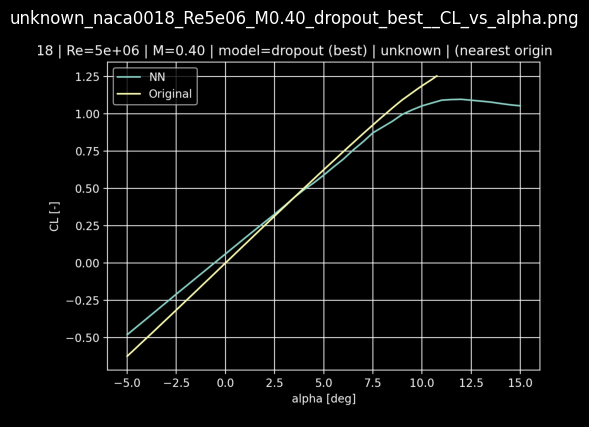

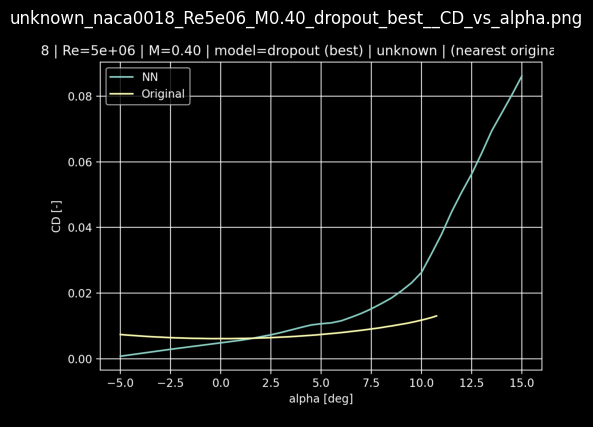

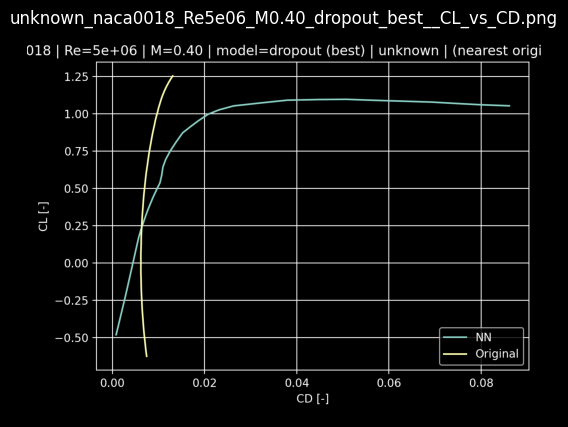

In [23]:
# ============================================================
# 4) Interactive evaluation run
# ============================================================
model_info = load_model_info(MODEL_INFO_NPY)
trained = list_trained_models(TRAINED_DIR)
if len(trained) == 0:
    raise FileNotFoundError(
        f"No trained model weights found in {TRAINED_DIR}. "
        f"Expected files like 'medium_best.pth' etc."
    )

X_mean, X_std, Y_mean, Y_std = load_normalization(TRAIN_NPZ)

df_train_rows = load_training_rows(TRAIN_ROWS_CSV) if TRAIN_ROWS_CSV.exists() else pd.DataFrame()
known_nacas, known_res, known_machs = available_known_sets(df_train_rows) if len(df_train_rows) else ([], [], [])
df_unknown_index = index_unknown_originals(ORIGINAL_POLARS_DIR)
unknown_nacas = sorted(df_unknown_index["naca_int"].unique().tolist()) if len(df_unknown_index) else []

print("\n" + "="*80)
print("AVAILABLE MODELS (trained weights found):")
for k, v in trained.items():
    tags = ", ".join(sorted(v.keys()))
    print(f"  - {k:10s}: {tags}")
print("="*80)

if len(known_nacas):
    print(f"\nKNOWN NACA profiles (from xfoil_dataset_rows.csv): {len(known_nacas)}")
    print("  Examples:", ", ".join([f"naca{n:04d}" for n in known_nacas[:20]]) + (" ..." if len(known_nacas) > 20 else ""))
    print(f"  Re range:   {min(known_res):.3g} .. {max(known_res):.3g}")
    print(f"  Mach range: {min(known_machs):.3f} .. {max(known_machs):.3f}")
else:
    print("\nKNOWN NACA profiles: none detected (missing/empty xfoil_dataset_rows.csv).")

if len(unknown_nacas):
    print(f"\nUNKNOWN original polars available (from data/processed/original_polars): {len(df_unknown_index)} files")
    print("  NACA options:", ", ".join([f"naca{n:04d}" for n in unknown_nacas]))
    print(f"  Re range:   {df_unknown_index['Re'].min():.3g} .. {df_unknown_index['Re'].max():.3g}")
    print(f"  Mach range: {df_unknown_index['Mach'].min():.3f} .. {df_unknown_index['Mach'].max():.3f}")
else:
    print("\nUNKNOWN original polars: none detected (data/processed/original_polars empty or missing).")

print("\nAoA sweep is fixed to: -5 to 15 deg, step 0.5 deg")
print("="*80 + "\n")

clear_output_dir(OUT_DIR)

mode = input("Evaluate KNOWN or UNKNOWN? [k/u] (default: k): ").strip().lower() or "k"
if mode not in ("k", "u"):
    raise ValueError("Mode must be 'k' (known) or 'u' (unknown).")

model_name = input(f"Select model {list(trained.keys())} (default: medium): ").strip().lower() or "medium"
if model_name not in trained:
    raise ValueError(f"Model '{model_name}' not found in trained_models. Available: {list(trained.keys())}")

which_weights = input(f"Use 'best' or 'weights'? Available: {list(trained[model_name].keys())} (default: best): ").strip().lower() or "best"
if which_weights not in trained[model_name]:
    which_weights = list(trained[model_name].keys())[0]
    print(f"[WARN] Requested weights not found. Falling back to '{which_weights}'.")

naca_in = input("Enter NACA code (e.g. 2412 or 0010 or naca2412): ").strip()
naca = parse_naca_code(naca_in)
naca_print = f"naca{naca:04d}"

Re = float(input("Enter Reynolds number (e.g. 2e6): ").strip())
Mach = float(input("Enter Mach number (e.g. 0.20): ").strip())

alphas = np.round(np.arange(-5.0, 15.0 + 1e-9, 0.5), 6)

model = build_model(model_name, model_info)
weights_path = trained[model_name][which_weights]
load_weights(model, weights_path)

orig_df = pd.DataFrame()
meta = {}

if mode == "k":
    if len(df_train_rows) == 0:
        print("[WARN] No xfoil_dataset_rows.csv available; will plot NN only.")
        Re_use, Mach_use = Re, Mach
        meta = {"naca_found": False}
    else:
        orig_df, meta = subset_original_known(df_train_rows, naca=naca, Re=Re, Mach=Mach)
        if not meta.get("naca_found", False):
            print(f"[WARN] NACA {naca_print} not found in xfoil_dataset_rows.csv; will plot NN only.")
            Re_use, Mach_use = Re, Mach
        else:
            if (not meta["Re_exact"]) or (not meta["Mach_exact"]):
                print("[INFO] Requested (Re, Mach) not exactly available in known dataset.")
                print(f"       Using nearest: Re={meta['Re_selected']:.3g}, Mach={meta['Mach_selected']:.3f}")
            Re_use = meta["Re_selected"]
            Mach_use = meta["Mach_selected"]
else:
    if len(df_unknown_index) == 0:
        print("[WARN] No unknown original polar CSVs found; will plot NN only.")
        Re_use, Mach_use = Re, Mach
        meta = {"naca_found": False}
    else:
        orig_df, meta = subset_original_unknown(df_unknown_index, naca=naca, Re=Re, Mach=Mach)
        if not meta.get("naca_found", False):
            print(f"[WARN] NACA {naca_print} not found in original_polars folder; will plot NN only.")
            Re_use, Mach_use = Re, Mach
        else:
            if (not meta["Re_exact"]) or (not meta["Mach_exact"]):
                print("[INFO] Requested (Re, Mach) not exactly available in unknown originals.")
                print(f"       Using nearest file: {meta['file']}")
                print(f"       Nearest: Re={meta['Re_selected']:.3g}, Mach={meta['Mach_selected']:.3f}")
            else:
                print(f"[INFO] Using file: {meta['file']}")
            Re_use = meta["Re_selected"]
            Mach_use = meta["Mach_selected"]

pred_df = predict_polar(
    model=model,
    naca=naca,
    Re=Re_use,
    Mach=Mach_use,
    alphas=alphas,
    X_mean=X_mean,
    X_std=X_std,
    Y_mean=Y_mean,
    Y_std=Y_std,
    device="cpu",
)

mode_tag = "known" if mode == "k" else "unknown"
tag = f"{mode_tag}_{naca_print}_Re{Re_use:.3g}_M{Mach_use:.2f}_{model_name}_{which_weights}"
tag = tag.replace("+", "").replace(" ", "_").replace("/", "_")

title_base = f"{naca_print} | Re={Re_use:.3g} | M={Mach_use:.2f} | model={model_name} ({which_weights}) | {mode_tag}"
if meta.get("naca_found", False) and ((not meta.get("Re_exact", True)) or (not meta.get("Mach_exact", True))):
    title_base += " | (nearest original)"

out1 = OUT_DIR / f"{tag}__CL_vs_alpha.png"
out2 = OUT_DIR / f"{tag}__CD_vs_alpha.png"
out3 = OUT_DIR / f"{tag}__CL_vs_CD.png"

save_plot_cl_alpha(pred_df, orig_df, title_base + " | CL vs alpha", out1)
save_plot_cd_alpha(pred_df, orig_df, title_base + " | CD vs alpha", out2)
save_plot_cl_cd(pred_df, orig_df, title_base + " | CL vs CD", out3)

print("\nSaved:")
print(" ", out1)
print(" ", out2)
print(" ", out3)

display(pred_df.head())
if orig_df is not None and len(orig_df) > 0:
    display(orig_df.head())

import matplotlib.image as mpimg
for p in [out1, out2, out3]:
    img = mpimg.imread(p)
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.name)
    plt.show()